**IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**UPLOAD FILES**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving employed_intnshp.csv to employed_intnshp.csv


**LOAD DATASETS**

In [5]:
unemp = pd.read_csv("unemployed_intnshp.csv")
emp = pd.read_csv("employed_intnshp.csv")

The datasets contain employment and unemployment rates for different countries across multiple years.

In [6]:
unemp.head()

,iso_code,country,sex,age,year,obs_value
0,AFG,Afghanistan,Total,15+,2025,13.351
1,AFG,Afghanistan,Total,15-24,2025,16.785
2,AFG,Afghanistan,Total,25+,2025,11.340
3,AFG,Afghanistan,Male,15+,2025,12.503
4,AFG,Afghanistan,Male,15-24,2025,15.814


In [7]:
emp.head()

,iso_code,country,sex,age,year,obs_value
0,AFG,Afghanistan,Total,15+,2025,32.457
1,AFG,Afghanistan,Total,15-24,2025,31.419
2,AFG,Afghanistan,Total,25+,2025,33.056
3,AFG,Afghanistan,Male,15+,2025,61.038
4,AFG,Afghanistan,Male,15-24,2025,57.355


In [8]:
unemp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57519 entries, 0 to 57518
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   iso_code   57519 non-null  object 
 1   country    57519 non-null  object 
 2   sex        57519 non-null  object 
 3   age        57519 non-null  object 
 4   year       57519 non-null  int64  
 5   obs_value  57519 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 2.6+ MB


In [9]:
emp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57519 entries, 0 to 57518
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   iso_code   57519 non-null  object 
 1   country    57519 non-null  object 
 2   sex        57519 non-null  object 
 3   age        57519 non-null  object 
 4   year       57519 non-null  int64  
 5   obs_value  57519 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 2.6+ MB


**1. Covid Recovery Time**

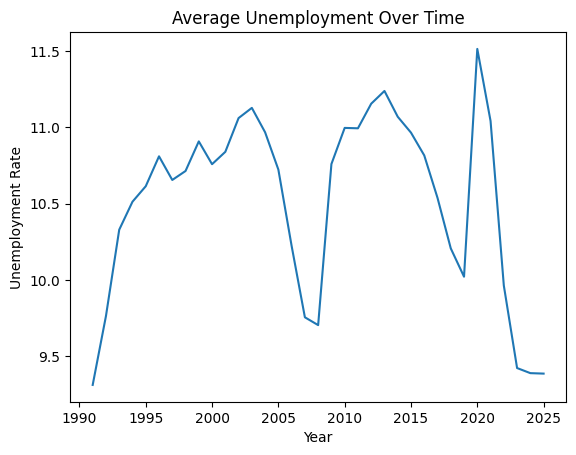

In [11]:
# Average unemployment by year
unemp_year = unemp.groupby("year")["obs_value"].mean().reset_index()

# Plot
plt.figure()
plt.plot(unemp_year["year"], unemp_year["obs_value"])
plt.title("Average Unemployment Over Time")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate")
plt.show()

Unemployment peaked in 2020 due to COVID-19 and gradually declined after 2021, indicating recovery within 1–3 years.

**2. Visualizations**

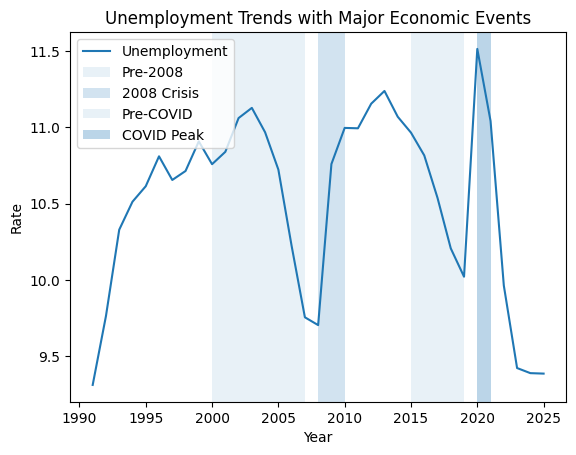

In [12]:
plt.figure()

plt.plot(unemp_year["year"], unemp_year["obs_value"], label="Unemployment")

# Mark important periods
plt.axvspan(2000, 2007, alpha=0.1, label="Pre-2008")
plt.axvspan(2008, 2010, alpha=0.2, label="2008 Crisis")
plt.axvspan(2015, 2019, alpha=0.1, label="Pre-COVID")
plt.axvspan(2020, 2021, alpha=0.3, label="COVID Peak")

plt.legend()
plt.title("Unemployment Trends with Major Economic Events")
plt.xlabel("Year")
plt.ylabel("Rate")
plt.show()

Unemployment remained stable before crises, spiked during 2008 and sharply increased again in 2020 due to COVID-19, which had a more sudden impact than the 2008 crisis.

**3. Sudden Spikes Or Drops**

In [13]:
# Calculate year-to-year change
unemp_year["change"] = unemp_year["obs_value"].diff()

# Biggest spikes
spikes = unemp_year.sort_values("change", ascending=False).head(5)

# Biggest drops
drops = unemp_year.sort_values("change").head(5)

spikes, drops

(    year  obs_value    change
 29  2020  11.513536  1.492480
 18  2009  10.759245  1.055404
 2   1993  10.328871  0.565373
 1   1992   9.763498  0.451522
 19  2010  10.996019  0.236775,
     year  obs_value    change
 31  2022   9.963206 -1.078052
 32  2023   9.422560 -0.540646
 15  2006  10.222560 -0.500264
 30  2021  11.041259 -0.472277
 16  2007   9.755146 -0.467413)

**INSIGHT**

Major Spikes occured in:

*   2008–2009 (financial crisis)
*   2020 (COVID-19)

Major drops occurred:

*   Post-2010 recovery
*   Post-2021 recovery

**4. Employment Trend (increase or decrease?)**

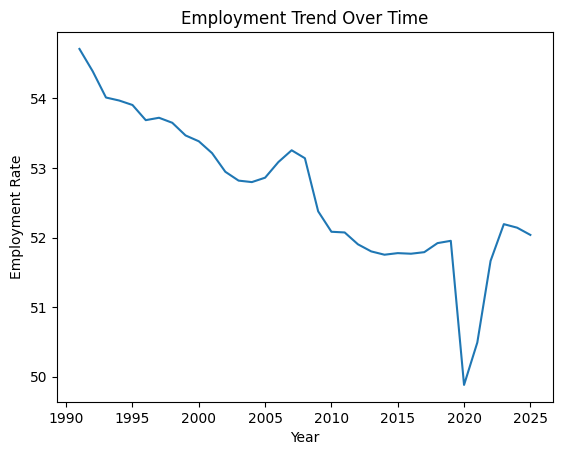

In [14]:
emp_year = emp.groupby("year")["obs_value"].mean().reset_index()

plt.figure()
plt.plot(emp_year["year"], emp_year["obs_value"])
plt.title("Employment Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Employment Rate")
plt.show()

**INSIGHT**

Employment generally increased over time for most countries, except for a sharp decline in 2020, followed by gradual recovery.